In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install chromadb sentence-transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 

In [8]:
from sentence_transformers import SentenceTransformer
import chromadb
import pandas as pd

# Load metadata catalog
metadata = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_metadata_catalog.csv")
print("Columns available:", metadata.columns.tolist())

# Initialize embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Initialize Chroma persistent client (store vector DB on Google Drive)
client = chromadb.PersistentClient(path="/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/ChromaDB")

# Create or get collection
collection = client.get_or_create_collection("argo_metadata")

# Prepare documents
docs, metas = [], []
for idx, row in metadata.iterrows():
    text = (
        f"File {row['file_path']} contains {row['num_rows']} measurements "
        f"from {row['year']}-{row['month']} "
        f"in region lat[{row['lat_min']}, {row['lat_max']}] "
        f"lon[{row['lon_min']}, {row['lon_max']}] "
        f"with depth range {row['depth_min']}–{row['depth_max']} meters."
    )
    docs.append(text)
    metas.append(row.to_dict())

# Generate embeddings
embeddings = embedder.encode(docs).tolist()

# Insert into Chroma (avoiding duplicates)
collection.add(
    documents=docs,
    embeddings=embeddings,
    metadatas=metas,
    ids=[str(i) for i in range(len(docs))]
)

print(f"Inserted {len(docs)} metadata entries into vector store.")


Columns available: ['file_path', 'year', 'month', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'depth_min', 'depth_max', 'num_rows']
Inserted 36 metadata entries into vector store.


In [19]:
def hybrid_retrieve(query, top_k=5, year=None, region=None, depth_range=None, return_paths=False):
    # Step 1: semantic search
    query_embedding = embedder.encode([query]).tolist()[0]
    results = collection.query(query_embeddings=[query_embedding], n_results=top_k)

    # Flatten metadata (Chroma returns [[...]])
    metadatas = results["metadatas"][0]
    df = pd.DataFrame(metadatas)

    # Step 2: apply filters
    if year:
        df = df[df["year"] == year]
    if region:
        df = df[
            (df["lat_min"] <= region["lat_max"]) &
            (df["lat_max"] >= region["lat_min"]) &
            (df["lon_min"] <= region["lon_max"]) &
            (df["lon_max"] >= region["lon_min"])
        ]
    if depth_range:
        df = df[
            (df["depth_min"] <= depth_range[1]) &
            (df["depth_max"] >= depth_range[0])
        ]

    df = df.reset_index(drop=True)

    if return_paths:
        return df, df["file_path"].tolist()
    else:
        return df


In [15]:
# Example 1: Simple semantic search
print(hybrid_retrieve("salinity at 500m Arabian Sea", top_k=5))

# Example 2: With filters
print(hybrid_retrieve(
    "temperature profiles",
    year=2019,
    region={"lat_min": 5, "lat_max": 20, "lon_min": 60, "lon_max": 75},  # Arabian Sea box
    depth_range=(400, 600)
))


     lat_min    depth_max    lat_max   lon_min  depth_min  num_rows  \
0 -39.927190  5331.600098  24.271975  30.16400       -0.1   1857945   
1 -39.975000  5005.100098  24.494892  30.18150        0.0   1736010   
2 -39.929090  4502.609863  26.758967  30.53059       -0.1   1465770   
3 -39.906908  4510.209961  25.096493  30.17752        0.0   1279043   
4 -39.950220  5307.600098  25.072393  30.01000       -0.2   1615402   

                                           file_path  year  month    lon_max  
0  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2023     10  109.82945  
1  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2023      7  109.94359  
2  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      4  109.89499  
3  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      2  109.77480  
4  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2023      9  109.65394  
Empty DataFrame
Columns: [lat_max, depth_min, lat_min, month, num_rows, depth_max, file_path, year,

In [20]:
df = hybrid_retrieve("salinity profiles", top_k=5)
print(df)


    depth_min    lon_min                                          file_path  \
0 -437.100006  30.439100  /content/drive/MyDrive/ColabNotebooks/SIH2025/...   
1    0.000000  30.110670  /content/drive/MyDrive/ColabNotebooks/SIH2025/...   
2   -3.700000  30.246017  /content/drive/MyDrive/ColabNotebooks/SIH2025/...   
3    0.000000  30.177520  /content/drive/MyDrive/ColabNotebooks/SIH2025/...   
4    0.000000  30.013950  /content/drive/MyDrive/ColabNotebooks/SIH2025/...   

   num_rows  year    lat_max    depth_max  month     lon_max    lat_min  
0   1662036  2022  24.942348  4543.000000     10  109.070297 -39.932850  
1   1772858  2023  24.823637  5189.899902     11  109.849586 -39.916000  
2   1870109  2024  23.585888  5135.399902     12  109.964513 -39.919750  
3   1279043  2022  25.096493  4510.209961      2  109.774800 -39.906908  
4   1410136  2022  25.345072  4530.000000      6  109.856300 -39.946530  


In [21]:
df, paths = hybrid_retrieve(
    "temperature profiles",
    year=2019,
    region={"lat_min": 5, "lat_max": 20, "lon_min": 60, "lon_max": 75},  # Arabian Sea box
    depth_range=(400, 600),
    return_paths=True
)

print("Matching files:")
for p in paths:
    print(p)


Matching files:


In [22]:
df, paths = hybrid_retrieve("temperature profiles", return_paths=True)
print("Matching files:", paths)


Matching files: ['/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_10_MINIMAL.parquet', '/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2023_11_MINIMAL.parquet', '/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_04_MINIMAL.parquet', '/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2024_10_MINIMAL.parquet', '/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_11_MINIMAL.parquet']


In [23]:
import xarray as xr

def load_netcdf_subset(paths, region=None, depth_range=None):
    datasets = []
    for p in paths:
        ds = xr.open_dataset(p)

        # Apply filters if requested
        if region:
            ds = ds.sel(
                latitude=slice(region["lat_min"], region["lat_max"]),
                longitude=slice(region["lon_min"], region["lon_max"])
            )
        if depth_range:
            ds = ds.sel(
                depth=slice(depth_range[0], depth_range[1])
            )
        datasets.append(ds)

    # Merge multiple files into one dataset
    if datasets:
        return xr.concat(datasets, dim="profile")
    else:
        return None


In [24]:
df, paths = hybrid_retrieve(
    "temperature profiles",
    year=2019,
    return_paths=True
)

ds = load_netcdf_subset(paths, region={"lat_min": 5, "lat_max": 20, "lon_min": 60, "lon_max": 75}, depth_range=(400,600))

print(ds)


None


In [25]:
from sentence_transformers import SentenceTransformer
import chromadb
import pandas as pd
import xarray as xr

def hybrid_retrieve_and_load(
    query,
    top_k=5,
    year=None,
    region=None,
    depth_range=None
):
    # Step 1: semantic search
    query_embedding = embedder.encode([query]).tolist()[0]
    results = collection.query(query_embeddings=[query_embedding], n_results=top_k)

    # Flatten metadata (Chroma returns [[...]])
    metadatas = results["metadatas"][0]
    df = pd.DataFrame(metadatas)

    # Step 2: apply filters
    if year:
        df = df[df["year"] == year]
    if region:
        df = df[
            (df["lat_min"] <= region["lat_max"]) &
            (df["lat_max"] >= region["lat_min"]) &
            (df["lon_min"] <= region["lon_max"]) &
            (df["lon_max"] >= region["lon_min"])
        ]
    if depth_range:
        df = df[
            (df["depth_min"] <= depth_range[1]) &
            (df["depth_max"] >= depth_range[0])
        ]

    df = df.reset_index(drop=True)

    if df.empty:
        print("⚠️ No matching files found for this query.")
        return None, []

    # Step 3: load NetCDFs
    paths = df["file_path"].tolist()
    datasets = []
    for p in paths:
        try:
            ds = xr.open_dataset(p)

            # Apply region/depth filters at the dataset level too
            if region and "latitude" in ds and "longitude" in ds:
                ds = ds.sel(
                    latitude=slice(region["lat_min"], region["lat_max"]),
                    longitude=slice(region["lon_min"], region["lon_max"])
                )
            if depth_range and "depth" in ds:
                ds = ds.sel(
                    depth=slice(depth_range[0], depth_range[1])
                )

            datasets.append(ds)
        except Exception as e:
            print(f"⚠️ Could not load {p}: {e}")

    if datasets:
        merged = xr.concat(datasets, dim="profile")
        return merged, paths
    else:
        return None, paths


In [27]:
ds, paths = hybrid_retrieve_and_load("temperature profiles", top_k=5)

print("Matching files:", paths)


⚠️ Could not load /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_10_MINIMAL.parquet: did not find a match in any of xarray's currently installed IO backends ['h5netcdf', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html
⚠️ Could not load /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2023_11_MINIMAL.parquet: did not find a match in any of xarray's currently installed IO backends ['h5netcdf', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html
⚠️ Could not load /content/drive/MyDrive/ColabNotebook

In [1]:
# --- INSTALL DEPENDENCIES ---
!pip install netCDF4 xarray pandas pyarrow fastparquet --quiet

import os
import pandas as pd
import xarray as xr

# --- DRIVE PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
catalog_path = os.path.join(drive_base, "argo_metadata_catalog.csv")
output_folder = os.path.join(drive_base, "Filtered_Argo")
os.makedirs(output_folder, exist_ok=True)

# --- LOAD CATALOG ---
catalog = pd.read_csv(catalog_path)
print("📑 Catalog loaded:", catalog.shape)

# --- QUERY PARAMETERS ---
query = {
    "years": [2022, 2023, 2024],  # List of years
    "lat_min": -20,
    "lat_max": 20,
    "lon_min": 30,
    "lon_max": 60,
    "depth_min": 0,
    "depth_max": 2000
}

# --- FILTER CATALOG FUNCTION ---
def filter_catalog(cat, q, year):
    filtered = cat.copy()
    filtered = filtered[filtered["year"] == year]
    filtered = filtered[
        (filtered["lat_max"] >= q["lat_min"]) &
        (filtered["lat_min"] <= q["lat_max"]) &
        (filtered["lon_max"] >= q["lon_min"]) &
        (filtered["lon_min"] <= q["lon_max"]) &
        (filtered["depth_max"] >= q["depth_min"]) &
        (filtered["depth_min"] <= q["depth_max"])
    ]
    return filtered

# --- UNIVERSAL LOADER ---
def load_file(file_path):
    try:
        if file_path.endswith(".nc"):
            ds = xr.open_dataset(file_path, decode_times=False)
            df = ds.to_dataframe().reset_index()
        elif file_path.endswith(".parquet"):
            df = pd.read_parquet(file_path)
        else:
            print(f"⚠️ Unsupported file type: {file_path}")
            return pd.DataFrame()
        df["source_file"] = file_path
        return df
    except Exception as e:
        print(f"❌ Error loading {file_path}: {e}")
        return pd.DataFrame()

# --- PROCESS YEAR-BY-YEAR ---
for year in query["years"]:
    print(f"\n🔹 Processing year {year} ...")
    matches = filter_catalog(catalog, query, year)

    if matches.empty:
        print(f"⚠️ No files found for {year}")
        continue

    all_data = []
    for f in matches["file_path"].tolist():
        if os.path.exists(f):
            print(f"📂 Loading {f} ...")
            df = load_file(f)
            if not df.empty:
                all_data.append(df)
        else:
            print(f"⚠️ File not found: {f}")

    # Save year-wise files
    if all_data:
        year_df = pd.concat(all_data, ignore_index=True)
        csv_path = os.path.join(output_folder, f"argo_filtered_{year}.csv")
        parquet_path = os.path.join(output_folder, f"argo_filtered_{year}.parquet")
        year_df.to_csv(csv_path, index=False)
        year_df.to_parquet(parquet_path, index=False)
        print(f"💾 Saved {year_df.shape[0]} rows for {year} to:")
        print(f"   CSV: {csv_path}")
        print(f"   Parquet: {parquet_path}")
    else:
        print(f"⚠️ No data loaded for {year}")


📑 Catalog loaded: (36, 10)

🔹 Processing year 2022 ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_01_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_02_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_03_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_04_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_05_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_06_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_07_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/argo_prototype_parquet/2022_08_MINIMAL.parquet ...
📂 Loading /content/drive/MyDrive/ColabNotebooks/S

In [2]:
# --- INSTALL DEPENDENCIES ---
!pip install pandas xarray pyarrow fastparquet matplotlib seaborn plotly --quiet

import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- STEP 1: SETUP DRIVE PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
catalog_path = os.path.join(drive_base, "argo_metadata_catalog.csv")
filtered_folder = os.path.join(drive_base, "filtered_argo_data")  # folder to save per-year files

# Create folder if not exists
os.makedirs(filtered_folder, exist_ok=True)

# --- STEP 2: LOAD CATALOG ---
catalog = pd.read_csv(catalog_path)
print("📑 Catalog loaded successfully")
print(catalog.head())

# --- STEP 3: DEFINE QUERY FUNCTION ---
def filter_catalog(catalog, year=None, lat_min=None, lat_max=None,
                   lon_min=None, lon_max=None, depth_min=None, depth_max=None):
    df = catalog.copy()
    if year is not None:
        df = df[df["year"] == year]
    if lat_min is not None and lat_max is not None:
        df = df[(df["lat_max"] >= lat_min) & (df["lat_min"] <= lat_max)]
    if lon_min is not None and lon_max is not None:
        df = df[(df["lon_max"] >= lon_min) & (df["lon_min"] <= lon_max)]
    if depth_min is not None and depth_max is not None:
        df = df[(df["depth_max"] >= depth_min) & (df["depth_min"] <= depth_max)]
    return df

# --- STEP 4: UNIVERSAL LOADER ---
def load_file(file_path):
    try:
        if file_path.endswith(".nc"):
            ds = xr.open_dataset(file_path, decode_times=False)
            df = ds.to_dataframe().reset_index()
        elif file_path.endswith(".parquet"):
            df = pd.read_parquet(file_path)
        else:
            print(f"⚠️ Unsupported file type: {file_path}")
            return pd.DataFrame()
        df["source_file"] = file_path
        return df
    except Exception as e:
        print(f"❌ Error loading {file_path}: {e}")
        return pd.DataFrame()

# --- STEP 5: LOAD YEAR-WISE DATA ---
def load_year_data(year, lat_min=-90, lat_max=90, lon_min=-180, lon_max=180, depth_min=0, depth_max=2000):
    print(f"\n🔹 Processing year {year} ...")
    matches = filter_catalog(catalog, year, lat_min, lat_max, lon_min, lon_max, depth_min, depth_max)

    if matches.empty:
        print(f"⚠️ No matching files found for {year}")
        return pd.DataFrame()

    all_data = []
    for f in matches["file_path"].tolist():
        if os.path.exists(f):
            df = load_file(f)
            if not df.empty:
                all_data.append(df)
        else:
            print(f"⚠️ File not found: {f}")

    if all_data:
        year_df = pd.concat(all_data, ignore_index=True)
        # Save to drive
        csv_path = os.path.join(filtered_folder, f"argo_{year}_filtered.csv")
        parquet_path = os.path.join(filtered_folder, f"argo_{year}_filtered.parquet")
        year_df.to_csv(csv_path, index=False)
        year_df.to_parquet(parquet_path, index=False)
        print(f"💾 Saved CSV: {csv_path}")
        print(f"💾 Saved Parquet: {parquet_path}")
        return year_df
    else:
        print(f"⚠️ No data loaded for {year}")
        return pd.DataFrame()

# --- STEP 6: VISUALIZATION FUNCTION ---
def plot_variable(df, var="TEMP_ADJUSTED", depth_col="DEPTH", interactive=False):
    if var not in df.columns or depth_col not in df.columns:
        print(f"⚠️ Columns {var} or {depth_col} not found in dataframe")
        return
    if interactive:
        fig = px.scatter(df, x=var, y=depth_col, color=depth_col, title=f"{var} vs {depth_col}")
        fig.update_yaxes(autorange="reversed")  # Depth increases downward
        fig.show()
    else:
        plt.figure(figsize=(8,6))
        sns.scatterplot(x=var, y=depth_col, data=df, alpha=0.3)
        plt.gca().invert_yaxis()
        plt.title(f"{var} vs {depth_col}")
        plt.show()

# --- STEP 7: USAGE EXAMPLES ---
# Load multiple years
years_to_load = [2022, 2023, 2024]
yearly_data = {}
for y in years_to_load:
    df = load_year_data(y, lat_min=-20, lat_max=20, lon_min=30, lon_max=60, depth_min=0, depth_max=2000)
    if not df.empty:
        yearly_data[y] = df

# Visualize a variable for 2022
if 2022 in yearly_data:
    plot_variable(yearly_data[2022], var="TEMP_ADJUSTED", depth_col="DEPTH", interactive=False)


📑 Catalog loaded successfully
                                           file_path  year  month    lat_min  \
0  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      1 -39.869000   
1  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      2 -39.906908   
2  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      3 -39.985000   
3  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      4 -39.929090   
4  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      5 -39.912000   

     lat_max   lon_min    lon_max  depth_min    depth_max  num_rows  
0  25.530760  30.86684  109.95030        0.0  4512.899902   1424143  
1  25.096493  30.17752  109.77480        0.0  4510.209961   1279043  
2  25.044137  31.17850  109.79900       -0.2  4512.849609   1396118  
3  26.758967  30.53059  109.89499       -0.1  4502.609863   1465770  
4  24.786320  31.01284  109.53160        0.0  4529.600098   1367667  

🔹 Processing year 2022 ...
💾 Saved CSV: /content/drive/MyDrive/Colab

In [3]:
# Example: check first 5 columns of 2022 data
df2022 = pd.read_parquet("/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/argo_2022_filtered.parquet")
print(df2022.columns)


Index(['LATITUDE', 'LONGITUDE', 'JULD', 'DEPTH_M', 'TEMP', 'PSAL',
       'source_file'],
      dtype='object')


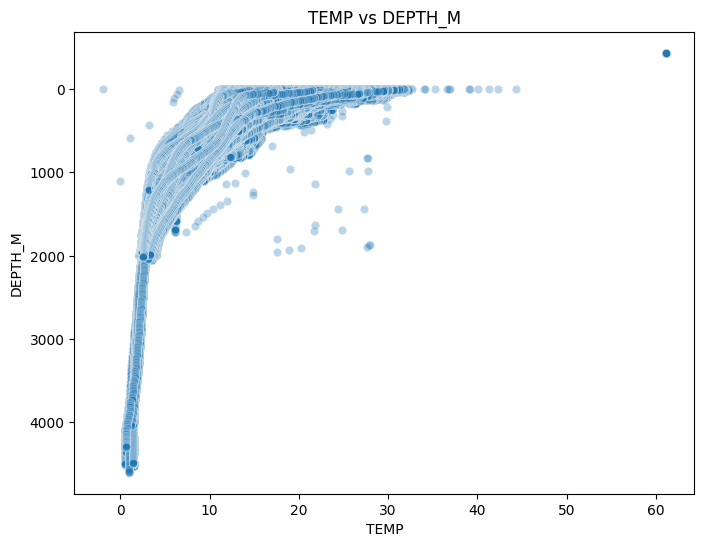

In [5]:
# Corrected call with actual column names
plot_variable(df2022, var="TEMP", depth_col="DEPTH_M", interactive=False)


In [6]:
# --- INSTALL DEPENDENCIES ---
!pip install matplotlib seaborn plotly pandas pyarrow

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- STEP 1: SETUP DRIVE PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data"
plot_save_dir = os.path.join(drive_base, "plots")
os.makedirs(plot_save_dir, exist_ok=True)

# --- STEP 2: DEFINE FUNCTION TO PLOT VARIABLES ---
def plot_variable(df, var="TEMP", depth_col="DEPTH_M", interactive=False, year=None):
    """
    Plots a variable vs depth.
    If interactive=True, uses Plotly, otherwise Matplotlib.
    Saves plot as PNG in Drive.
    """
    if var not in df.columns:
        print(f"⚠️ Column '{var}' not found in dataframe")
        return
    if depth_col not in df.columns:
        print(f"⚠️ Column '{depth_col}' not found in dataframe")
        return

    plt.figure(figsize=(6, 8))
    sns.scatterplot(x=var, y=depth_col, data=df.sample(min(5000, len(df))), alpha=0.3)
    plt.gca().invert_yaxis()
    plt.xlabel(var)
    plt.ylabel("Depth (m)")
    plt.title(f"{var} vs Depth")
    plt.grid(True)

    filename = f"{var}_vs_depth_{year}.png" if year else f"{var}_vs_depth.png"
    save_path = os.path.join(plot_save_dir, filename)
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"💾 Saved plot: {save_path}")

    if interactive:
        fig = px.scatter(df.sample(min(5000, len(df))), x=var, y=depth_col,
                         title=f"{var} vs Depth",
                         labels={var: var, depth_col: "Depth (m)"})
        fig.update_yaxes(autorange="reversed")
        fig.show()

# --- STEP 3: PLOT FOR ALL YEARS ---
years = [2022, 2023, 2024]
variables = ["TEMP", "PSAL"]  # temperature and salinity

for y in years:
    file_path = os.path.join(drive_base, f"argo_{y}_filtered.parquet")
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        continue

    print(f"\n🔹 Processing year {y} ...")
    df = pd.read_parquet(file_path)

    # Detect depth column (default DEPTH_M)
    depth_col = "DEPTH_M" if "DEPTH_M" in df.columns else "PRES"

    for var in variables:
        if var in df.columns:
            plot_variable(df, var=var, depth_col=depth_col, interactive=False, year=y)
        else:
            print(f"⚠️ Column '{var}' not found in {file_path}")



🔹 Processing year 2022 ...
💾 Saved plot: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/plots/TEMP_vs_depth_2022.png
💾 Saved plot: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/plots/PSAL_vs_depth_2022.png

🔹 Processing year 2023 ...
💾 Saved plot: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/plots/TEMP_vs_depth_2023.png
💾 Saved plot: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/plots/PSAL_vs_depth_2023.png

🔹 Processing year 2024 ...
💾 Saved plot: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/plots/TEMP_vs_depth_2024.png
💾 Saved plot: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/plots/PSAL_vs_depth_2024.png


📑 Catalog loaded:
                                           file_path  year  month    lat_min  \
0  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      1 -39.869000   
1  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      2 -39.906908   
2  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      3 -39.985000   
3  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      4 -39.929090   
4  /content/drive/MyDrive/ColabNotebooks/SIH2025/...  2022      5 -39.912000   

     lat_max   lon_min    lon_max  depth_min    depth_max  num_rows  
0  25.530760  30.86684  109.95030        0.0  4512.899902   1424143  
1  25.096493  30.17752  109.77480        0.0  4510.209961   1279043  
2  25.044137  31.17850  109.79900       -0.2  4512.849609   1396118  
3  26.758967  30.53059  109.89499       -0.1  4502.609863   1465770  
4  24.786320  31.01284  109.53160        0.0  4529.600098   1367667  


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Inserted 36 metadata entries into ChromaDB.
✅ Found 3 matching files:


,file_path,year,lat_min,lat_max,lon_min,lon_max
0,/content/drive/MyDrive/ColabNotebooks/SIH2025/...,2022,-39.93285,24.942348,30.439100,109.070297
2,/content/drive/MyDrive/ColabNotebooks/SIH2025/...,2022,-39.92909,26.758967,30.530590,109.894990
4,/content/drive/MyDrive/ColabNotebooks/SIH2025/...,2022,-39.96375,24.394670,30.029153,109.926760


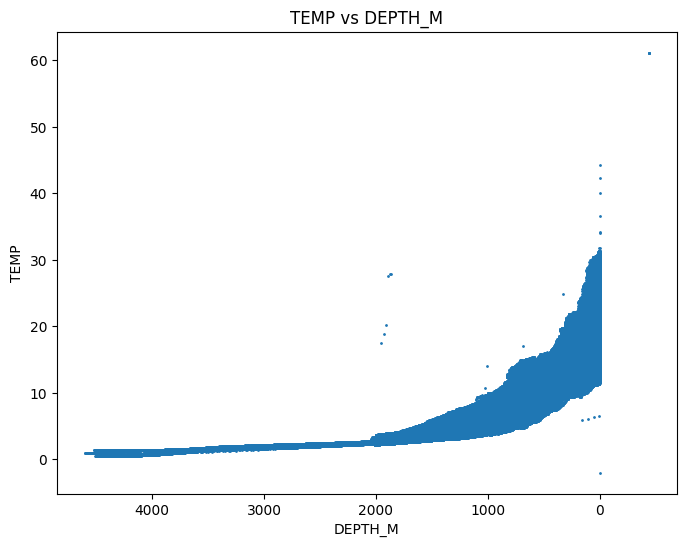

In [7]:
# --- INSTALL DEPENDENCIES ---
!pip install sentence-transformers chromadb pandas xarray pyarrow fastparquet

import os
import pandas as pd
from sentence_transformers import SentenceTransformer
import chromadb
import xarray as xr

# --- STEP 1: SETUP PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
catalog_path = os.path.join(drive_base, "argo_metadata_catalog.csv")
chroma_path = os.path.join(drive_base, "ChromaDB")  # Persistent vector store path

# --- STEP 2: LOAD METADATA CATALOG ---
catalog = pd.read_csv(catalog_path)
print("📑 Catalog loaded:")
print(catalog.head())

# --- STEP 3: INITIALIZE EMBEDDING MODEL ---
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# --- STEP 4: INITIALIZE CHROMADB ---
client = chromadb.PersistentClient(path=chroma_path)
# Create or get collection
collection_name = "argo_metadata"
try:
    collection = client.create_collection(name=collection_name)
except Exception:
    collection = client.get_collection(name=collection_name)

# --- STEP 5: PREPARE DOCUMENTS (METADATA) ---
docs, metas, ids = [], [], []

for idx, row in catalog.iterrows():
    text = (
        f"File {row['file_path']} contains {row['num_rows']} measurements "
        f"from {row['year']}-{row['month']} "
        f"in region lat[{row['lat_min']}, {row['lat_max']}] "
        f"lon[{row['lon_min']}, {row['lon_max']}] "
        f"with depth range {row['depth_min']}–{row['depth_max']} meters."
    )
    docs.append(text)
    metas.append(row.to_dict())
    ids.append(str(idx))

# --- STEP 6: GENERATE EMBEDDINGS (IN BATCHES FOR SPEED) ---
batch_size = 128
embeddings = []
for i in range(0, len(docs), batch_size):
    batch_emb = embedder.encode(docs[i:i+batch_size]).tolist()
    embeddings.extend(batch_emb)

# --- STEP 7: INSERT INTO CHROMADB ---
collection.add(
    documents=docs,
    embeddings=embeddings,
    metadatas=metas,
    ids=ids
)
print(f"✅ Inserted {len(docs)} metadata entries into ChromaDB.")

# --- STEP 8: HYBRID RETRIEVAL FUNCTION ---
def hybrid_retrieve(query_text, top_k=5, lat_range=None, lon_range=None, year=None):
    # Semantic search
    query_emb = embedder.encode([query_text]).tolist()
    results = collection.query(
        query_embeddings=query_emb,
        n_results=top_k
    )

    # Convert to DataFrame
    df = pd.DataFrame(results['metadatas'][0])

    # Apply additional filters
    if year:
        df = df[df['year'] == year]
    if lat_range:
        df = df[(df['lat_min'] <= lat_range[1]) & (df['lat_max'] >= lat_range[0])]
    if lon_range:
        df = df[(df['lon_min'] <= lon_range[1]) & (df['lon_max'] >= lon_range[0])]

    if df.empty:
        print("⚠️ No matching files found.")
    else:
        print(f"✅ Found {len(df)} matching files:")
        display(df[['file_path','year','lat_min','lat_max','lon_min','lon_max']])
    return df

# --- STEP 9: FUNCTION TO LOAD AND PLOT VARIABLES ---
def load_and_plot(file_paths, var="TEMP", depth_col="DEPTH_M", interactive=False):
    import matplotlib.pyplot as plt
    all_data = []

    for f in file_paths:
        if os.path.exists(f):
            try:
                if f.endswith(".parquet"):
                    df = pd.read_parquet(f)
                elif f.endswith(".nc"):
                    ds = xr.open_dataset(f, decode_times=False)
                    df = ds.to_dataframe().reset_index()
                else:
                    continue
                all_data.append(df)
            except Exception as e:
                print(f"❌ Error loading {f}: {e}")

    if all_data:
        combined = pd.concat(all_data, ignore_index=True)
        if var not in combined.columns or depth_col not in combined.columns:
            print(f"⚠️ Columns {var} or {depth_col} not found in data")
            return

        # Simple static plot
        plt.figure(figsize=(8,6))
        plt.scatter(combined[depth_col], combined[var], s=1)
        plt.xlabel(depth_col)
        plt.ylabel(var)
        plt.title(f"{var} vs {depth_col}")
        plt.gca().invert_xaxis()  # Depth usually plotted inverted
        plt.show()
    else:
        print("⚠️ No data loaded for plotting.")

# --- USAGE EXAMPLE ---
# Retrieve files with semantic query + year filter
matching_files = hybrid_retrieve("temperature profiles", year=2022)
# Load and plot TEMP vs DEPTH_M
if not matching_files.empty:
    load_and_plot(matching_files['file_path'].tolist(), var="TEMP", depth_col="DEPTH_M")


In [9]:
# --- INSTALL DEPENDENCIES ---
!pip install sentence-transformers chromadb xarray pandas pyarrow fastparquet plotly --quiet

import os
import pandas as pd
import xarray as xr
from sentence_transformers import SentenceTransformer
import chromadb
import plotly.express as px

# --- STEP 1: SETUP PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
catalog_path = os.path.join(drive_base, "argo_metadata_catalog.csv")
filtered_dir = os.path.join(drive_base, "filtered_argo_data")
os.makedirs(filtered_dir, exist_ok=True)

# --- STEP 2: LOAD CATALOG ---
catalog = pd.read_csv(catalog_path)
print("📑 Catalog loaded:", catalog.shape)
print(catalog.head())

# --- STEP 3: INITIALIZE EMBEDDING MODEL & VECTOR STORE ---
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Chroma Persistent Client
collection_path = os.path.join(drive_base, "ChromaDB")
client = chromadb.PersistentClient(path=collection_path)

collection_name = "argo_metadata"
try:
    collection = client.get_collection(name=collection_name)
except:
    collection = client.create_collection(name=collection_name)

# --- STEP 4: PREPARE METADATA EMBEDDINGS ---
docs, metas = [], []
for idx, row in catalog.iterrows():
    text = (
        f"File {row['file_path']} contains {row['num_rows']} measurements "
        f"from {row['year']}-{row['month']} "
        f"in region lat[{row['lat_min']}, {row['lat_max']}] "
        f"lon[{row['lon_min']}, {row['lon_max']}] "
        f"with depth range {row['depth_min']}–{row['depth_max']} meters."
    )
    docs.append(text)
    metas.append(row.to_dict())

# Generate embeddings
print("🔹 Generating embeddings...")
embeddings = embedder.encode(docs).tolist()

# Insert into ChromaDB (skip if already exists)
try:
    collection.add(
        documents=docs,
        embeddings=embeddings,
        metadatas=metas,
        ids=[str(i) for i in range(len(docs))]
    )
    print(f"✅ Inserted {len(docs)} entries into vector store.")
except Exception as e:
    print("⚠️ Possibly already added:", e)

# --- STEP 5: HYBRID RETRIEVAL FUNCTION ---
def hybrid_retrieve(query_text, year=None, lat_min=None, lat_max=None,
                    lon_min=None, lon_max=None, depth_min=None, depth_max=None, top_k=5):
    # Semantic retrieval
    query_emb = embedder.encode([query_text]).tolist()
    results = collection.query(query_embeddings=query_emb, n_results=top_k)

    # Convert to DataFrame
    matched_files = pd.DataFrame(results['metadatas'][0])

    # Apply metadata filters if provided
    if year is not None:
        matched_files = matched_files[matched_files['year'] == year]
    if lat_min is not None:
        matched_files = matched_files[matched_files['lat_max'] >= lat_min]
    if lat_max is not None:
        matched_files = matched_files[matched_files['lat_min'] <= lat_max]
    if lon_min is not None:
        matched_files = matched_files[matched_files['lon_max'] >= lon_min]
    if lon_max is not None:
        matched_files = matched_files[matched_files['lon_min'] <= lon_max]
    if depth_min is not None:
        matched_files = matched_files[matched_files['depth_max'] >= depth_min]
    if depth_max is not None:
        matched_files = matched_files[matched_files['depth_min'] <= depth_max]

    return matched_files

# --- STEP 6: LAZY FILE LOADER ---
def load_file_lazy(file_path):
    try:
        if file_path.endswith(".nc"):
            ds = xr.open_dataset(file_path, decode_times=False)
            df = ds.to_dataframe().reset_index()
        elif file_path.endswith(".parquet"):
            df = pd.read_parquet(file_path)
        else:
            return pd.DataFrame()
        df["source_file"] = file_path
        return df
    except Exception as e:
        print(f"❌ Error loading {file_path}: {e}")
        return pd.DataFrame()

# --- STEP 7: MERGE DATA FROM RETRIEVAL ---
def get_data_for_query(query_text, year=None, lat_min=None, lat_max=None,
                       lon_min=None, lon_max=None, depth_min=None, depth_max=None):
    files = hybrid_retrieve(query_text, year, lat_min, lat_max, lon_min, lon_max, depth_min, depth_max)
    if files.empty:
        print("⚠️ No files found for this query")
        return pd.DataFrame()

    print(f"📂 Loading {len(files)} matching files...")
    all_data = []
    for f in files['file_path']:
        if os.path.exists(f):
            df = load_file_lazy(f)
            if not df.empty:
                all_data.append(df)
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        return final_df
    else:
        print("⚠️ No data loaded from matching files")
        return pd.DataFrame()

# --- STEP 8: INTERACTIVE PLOTTING ---
def plot_variable(df, var="TEMP", depth_col="DEPTH_M", interactive=True):
    if df.empty or var not in df.columns or depth_col not in df.columns:
        print(f"⚠️ Columns {var} or {depth_col} not found in dataframe")
        return
    if interactive:
        fig = px.scatter(df, x="LONGITUDE", y=depth_col, color=var,
                         color_continuous_scale="Viridis", height=600,
                         title=f"{var} vs {depth_col}")
        fig.update_yaxes(autorange="reversed")  # depth increasing downward
        fig.show()
    else:
        import matplotlib.pyplot as plt
        plt.scatter(df["LONGITUDE"], df[depth_col], c=df[var], cmap="viridis", s=2)
        plt.gca().invert_yaxis()
        plt.xlabel("Longitude")
        plt.ylabel(depth_col)
        plt.title(f"{var} vs {depth_col}")
        plt.colorbar(label=var)
        plt.show()

# --- STEP 9: EXAMPLE QUERY & PLOT ---
query_text = "temperature profiles"
df2022 = get_data_for_query(query_text, year=2022, lat_min=-20, lat_max=20, lon_min=30, lon_max=60, depth_min=0, depth_max=2000)

if not df2022.empty:
    plot_variable(df2022, var="TEMP", depth_col="DEPTH_M", interactive=True)


Output hidden; open in https://colab.research.google.com to view.

In [10]:
# --- INSTALL DEPENDENCIES ---
!pip install sentence-transformers chromadb xarray pandas pyarrow fastparquet plotly --quiet

import os
import pandas as pd
import xarray as xr
from sentence_transformers import SentenceTransformer
import chromadb
import plotly.express as px

# --- STEP 1: SETUP PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
catalog_path = os.path.join(drive_base, "argo_metadata_catalog.csv")
filtered_dir = os.path.join(drive_base, "filtered_argo_data")
os.makedirs(filtered_dir, exist_ok=True)

# --- STEP 2: LOAD CATALOG ---
catalog = pd.read_csv(catalog_path)
print("📑 Catalog loaded:", catalog.shape)

# --- STEP 3: INITIALIZE EMBEDDING MODEL & VECTOR STORE ---
embedder = SentenceTransformer("all-MiniLM-L6-v2")

collection_path = os.path.join(drive_base, "ChromaDB")
client = chromadb.PersistentClient(path=collection_path)

collection_name = "argo_metadata"
try:
    collection = client.get_collection(name=collection_name)
except:
    collection = client.create_collection(name=collection_name)

# --- STEP 4: GENERATE EMBEDDINGS (if not already done) ---
if len(collection.get()) == 0:  # insert only if empty
    docs, metas = [], []
    for idx, row in catalog.iterrows():
        text = (
            f"File {row['file_path']} contains {row['num_rows']} measurements "
            f"from {row['year']}-{row['month']} "
            f"in region lat[{row['lat_min']}, {row['lat_max']}] "
            f"lon[{row['lon_min']}, {row['lon_max']}] "
            f"with depth range {row['depth_min']}–{row['depth_max']} meters."
        )
        docs.append(text)
        metas.append(row.to_dict())
    embeddings = embedder.encode(docs).tolist()
    collection.add(
        documents=docs,
        embeddings=embeddings,
        metadatas=metas,
        ids=[str(i) for i in range(len(docs))]
    )
    print(f"✅ Added {len(docs)} entries to vector store.")
else:
    print("✅ Embeddings already exist in ChromaDB")

# --- STEP 5: HYBRID RETRIEVAL FUNCTION ---
def hybrid_retrieve(query_text, year=None, lat_min=None, lat_max=None,
                    lon_min=None, lon_max=None, depth_min=None, depth_max=None, top_k=10):
    query_emb = embedder.encode([query_text]).tolist()
    results = collection.query(query_embeddings=query_emb, n_results=top_k)
    matched_files = pd.DataFrame(results['metadatas'][0])

    # Apply metadata filters
    if year is not None:
        matched_files = matched_files[matched_files['year'] == year]
    if lat_min is not None:
        matched_files = matched_files[matched_files['lat_max'] >= lat_min]
    if lat_max is not None:
        matched_files = matched_files[matched_files['lat_min'] <= lat_max]
    if lon_min is not None:
        matched_files = matched_files[matched_files['lon_max'] >= lon_min]
    if lon_max is not None:
        matched_files = matched_files[matched_files['lon_min'] <= lon_max]
    if depth_min is not None:
        matched_files = matched_files[matched_files['depth_max'] >= depth_min]
    if depth_max is not None:
        matched_files = matched_files[matched_files['depth_min'] <= depth_max]

    return matched_files

# --- STEP 6: LAZY FILE LOADER ---
def load_file_lazy(file_path):
    try:
        if file_path.endswith(".nc"):
            ds = xr.open_dataset(file_path, decode_times=False)
            df = ds.to_dataframe().reset_index()
        elif file_path.endswith(".parquet"):
            df = pd.read_parquet(file_path)
        else:
            return pd.DataFrame()
        df["source_file"] = file_path
        return df
    except Exception as e:
        print(f"❌ Error loading {file_path}: {e}")
        return pd.DataFrame()

# --- STEP 7: PROCESS MULTIPLE YEARS & SAVE ---
def process_years(query_text, years, lat_min, lat_max, lon_min, lon_max, depth_min, depth_max):
    for yr in years:
        print(f"\n🔹 Processing year {yr} ...")
        files = hybrid_retrieve(query_text, year=yr, lat_min=lat_min, lat_max=lat_max,
                                lon_min=lon_min, lon_max=lon_max, depth_min=depth_min, depth_max=depth_max)
        if files.empty:
            print(f"⚠️ No files found for year {yr}")
            continue

        all_data = []
        for f in files['file_path']:
            if os.path.exists(f):
                df = load_file_lazy(f)
                if not df.empty:
                    all_data.append(df)
        if all_data:
            final_df = pd.concat(all_data, ignore_index=True)
            csv_path = os.path.join(filtered_dir, f"argo_{yr}_filtered.csv")
            parquet_path = os.path.join(filtered_dir, f"argo_{yr}_filtered.parquet")
            final_df.to_csv(csv_path, index=False)
            final_df.to_parquet(parquet_path, index=False)
            print(f"💾 Saved CSV: {csv_path}")
            print(f"💾 Saved Parquet: {parquet_path}")
        else:
            print(f"⚠️ No data loaded for year {yr}")

# --- STEP 8: INTERACTIVE PLOTTING ---
def plot_variable(df, var="TEMP", depth_col="DEPTH_M", interactive=True):
    if df.empty or var not in df.columns or depth_col not in df.columns:
        print(f"⚠️ Columns {var} or {depth_col} not found in dataframe")
        return
    if interactive:
        fig = px.scatter(df, x="LONGITUDE", y=depth_col, color=var,
                         color_continuous_scale="Viridis", height=600,
                         title=f"{var} vs {depth_col}")
        fig.update_yaxes(autorange="reversed")
        fig.show()
    else:
        import matplotlib.pyplot as plt
        plt.scatter(df["LONGITUDE"], df[depth_col], c=df[var], cmap="viridis", s=2)
        plt.gca().invert_yaxis()
        plt.xlabel("Longitude")
        plt.ylabel(depth_col)
        plt.title(f"{var} vs {depth_col}")
        plt.colorbar(label=var)
        plt.show()

# --- STEP 9: RUN MULTI-YEAR PROCESSING ---
query_text = "temperature profiles"
years_to_process = catalog["year"].unique()
process_years(query_text, years_to_process, lat_min=-20, lat_max=20, lon_min=30, lon_max=60, depth_min=0, depth_max=2000)


📑 Catalog loaded: (36, 10)
✅ Embeddings already exist in ChromaDB

🔹 Processing year 2022 ...
💾 Saved CSV: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/argo_2022_filtered.csv
💾 Saved Parquet: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/argo_2022_filtered.parquet

🔹 Processing year 2023 ...
💾 Saved CSV: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/argo_2023_filtered.csv
💾 Saved Parquet: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/argo_2023_filtered.parquet

🔹 Processing year 2024 ...
💾 Saved CSV: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/argo_2024_filtered.csv
💾 Saved Parquet: /content/drive/MyDrive/ColabNotebooks/SIH2025/Data/filtered_argo_data/argo_2024_filtered.parquet


In [11]:
# --- INSTALL DEPENDENCIES ---
!pip install pandas xarray pyarrow fastparquet plotly

import os
import pandas as pd
import plotly.express as px

# --- STEP 1: SETUP PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
filtered_dir = os.path.join(drive_base, "filtered_argo_data")

# Check available filtered files
filtered_files = [f for f in os.listdir(filtered_dir) if f.endswith(".csv")]
print("📂 Filtered files available:", filtered_files)

# --- STEP 2: FUNCTION TO LOAD AND STANDARDIZE DATA ---
def load_and_standardize(file_path):
    """
    Load filtered CSV and standardize column names to:
    LATITUDE, LONGITUDE, JULD, DEPTH_M, TEMP, PSAL
    """
    df = pd.read_csv(file_path)
    # Rename columns if needed
    rename_map = {
        "LAT": "LATITUDE",
        "LON": "LONGITUDE",
        "TEMP_ADJUSTED": "TEMP",
        "DEPTH": "DEPTH_M"
    }
    df.rename(columns=rename_map, inplace=True)

    # Ensure required columns exist
    required_cols = ["LATITUDE", "LONGITUDE", "JULD", "DEPTH_M", "TEMP", "PSAL"]
    for col in required_cols:
        if col not in df.columns:
            df[col] = pd.NA  # fill missing columns with NA

    return df[required_cols + ["source_file"]]

# --- STEP 3: FUNCTION TO PLOT VARIABLE ---
def plot_variable(df, var="TEMP", depth_col="DEPTH_M", interactive=True):
    if df.empty or var not in df.columns or depth_col not in df.columns:
        print(f"⚠️ Columns {var} or {depth_col} not found in dataframe")
        return

    if interactive:
        fig = px.scatter(
            df, x="LONGITUDE", y=depth_col, color=var,
            color_continuous_scale="Viridis", height=600,
            title=f"{var} vs {depth_col}"
        )
        fig.update_yaxes(autorange="reversed")  # depth increases downward
        fig.show()
    else:
        import matplotlib.pyplot as plt
        plt.scatter(df["LONGITUDE"], df[depth_col], c=df[var], cmap="viridis", s=2)
        plt.gca().invert_yaxis()
        plt.xlabel("Longitude")
        plt.ylabel(depth_col)
        plt.title(f"{var} vs {depth_col}")
        plt.colorbar(label=var)
        plt.show()

# --- STEP 4: FUNCTION TO COMPUTE REGIONAL SUMMARY ---
def compute_summary(df, depth_interval=100):
    """
    Compute mean TEMP and PSAL by depth intervals.
    """
    if df.empty:
        return pd.DataFrame()

    df["DEPTH_BIN"] = (df["DEPTH_M"] // depth_interval) * depth_interval
    summary = df.groupby("DEPTH_BIN")[["TEMP", "PSAL"]].mean().reset_index()
    return summary

# --- STEP 5: EXAMPLE RUN FOR ALL YEARS ---
for file_name in filtered_files:
    file_path = os.path.join(filtered_dir, file_name)
    print(f"\n🔹 Processing file: {file_name}")

    df = load_and_standardize(file_path)
    print("✅ Loaded dataframe shape:", df.shape)

    # Plot TEMP vs DEPTH_M
    plot_variable(df, var="TEMP", depth_col="DEPTH_M", interactive=True)

    # Compute summary statistics
    summary_df = compute_summary(df, depth_interval=100)
    print("📊 Summary statistics by depth (first 10 rows):")
    print(summary_df.head(10))


Output hidden; open in https://colab.research.google.com to view.

In [3]:
# --- INSTALL DEPENDENCIES ---
!pip install pandas xarray pyarrow fastparquet plotly --quiet

import os
import re
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# --- STEP 1: SETUP PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
filtered_dir = os.path.join(drive_base, "filtered_argo_data")

# Check available filtered files
filtered_files = [f for f in os.listdir(filtered_dir) if f.endswith(".csv")]
print("📂 Filtered files available:", filtered_files)

# --- STEP 2: LOAD AND STANDARDIZE DATA (memory safe) ---
def load_and_standardize(file_path):
    """Load CSV, standardize column names, add missing cols, extract YEAR"""
    df = pd.read_csv(file_path)
    rename_map = {
        "LAT": "LATITUDE",
        "LON": "LONGITUDE",
        "TEMP_ADJUSTED": "TEMP",
        "DEPTH": "DEPTH_M"
    }
    df.rename(columns=rename_map, inplace=True)

    required_cols = ["LATITUDE", "LONGITUDE", "JULD", "DEPTH_M", "TEMP", "PSAL"]
    for col in required_cols:
        if col not in df.columns:
            df[col] = pd.NA

    # Extract year from file name
    year_match = re.search(r'(\d{4})', file_path)
    df["YEAR"] = int(year_match.group(1)) if year_match else pd.NA
    df["source_file"] = os.path.basename(file_path)

    return df[required_cols + ["source_file", "YEAR"]]

# --- STEP 3: COMPUTE SUMMARY BY YEAR & DEPTH BIN ---
def compute_summary_by_year(file_path, depth_interval=100):
    """Compute mean TEMP and PSAL per YEAR and DEPTH_BIN for a single file"""
    df = load_and_standardize(file_path)
    df["DEPTH_BIN"] = (df["DEPTH_M"] // depth_interval) * depth_interval
    summary = df.groupby(["YEAR", "DEPTH_BIN"])[["TEMP", "PSAL"]].mean().reset_index()
    return summary

# --- STEP 4: COMBINE SUMMARIES FROM ALL FILES ---
all_summaries = []
for file_name in filtered_files:
    file_path = os.path.join(filtered_dir, file_name)
    print(f"🔹 Processing {file_name} ...")
    summary = compute_summary_by_year(file_path, depth_interval=100)
    all_summaries.append(summary)

summary_df = pd.concat(all_summaries, ignore_index=True)
print("✅ Combined summary shape:", summary_df.shape)
print(summary_df.head(20))

# Optional: Save summary to CSV
summary_path = os.path.join(drive_base, "argo_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"📄 Summary saved to {summary_path}")

# --- STEP 5: PLOT MULTI-YEAR VARIABLES FROM SUMMARY ---
def plot_summary_variable(summary_df, var="TEMP"):
    fig = go.Figure()
    for year in sorted(summary_df["YEAR"].dropna().unique()):
        year_data = summary_df[summary_df["YEAR"] == year]
        fig.add_trace(go.Scatter(
            x=year_data[var],
            y=year_data["DEPTH_BIN"],
            mode="lines+markers",
            name=str(year)
        ))
    fig.update_yaxes(autorange="reversed", title_text="Depth (m)")
    fig.update_xaxes(title_text=var)
    fig.update_layout(title=f"Average {var} by Depth Bin")
    fig.show()

# Plot TEMP
plot_summary_variable(summary_df, var="TEMP")
# Plot PSAL
plot_summary_variable(summary_df, var="PSAL")


📂 Filtered files available: ['argo_2022_filtered.csv', 'argo_2023_filtered.csv', 'argo_2024_filtered.csv']
🔹 Processing argo_2022_filtered.csv ...
🔹 Processing argo_2023_filtered.csv ...
🔹 Processing argo_2024_filtered.csv ...
✅ Combined summary shape: (161, 4)
    YEAR  DEPTH_BIN       TEMP       PSAL
0   2025     -500.0  61.166000  61.166000
1   2025     -100.0  33.533333   0.035667
2   2025        0.0  22.707559  34.623503
3   2025      100.0  17.898483  34.721525
4   2025      200.0  15.053747  34.738191
5   2025      300.0  13.027550  34.578636
6   2025      400.0  11.433518  34.293986
7   2025      500.0  10.455485  34.195841
8   2025      600.0   9.546266  34.107468
9   2025      700.0   8.581877  34.013323
10  2025      800.0   7.413637  33.857805
11  2025      900.0   6.478525  33.839147
12  2025     1000.0   5.703751  34.092853
13  2025     1100.0   5.126480  34.125456
14  2025     1200.0   4.669214  34.296517
15  2025     1300.0   4.274321  34.303744
16  2025     1400.0   3.

In [2]:
# --- INSTALL DEPENDENCIES ---
!pip install xarray pandas pyarrow fastparquet plotly sentence-transformers chromadb

import os
import pandas as pd
import xarray as xr
import plotly.express as px
from sentence_transformers import SentenceTransformer
import chromadb

# --- STEP 1: SETUP PATHS ---
drive_base = "/content/drive/MyDrive/ColabNotebooks/SIH2025/Data"
filtered_dir = os.path.join(drive_base, "filtered_argo_data")
os.makedirs(filtered_dir, exist_ok=True)

# --- STEP 2: LOAD CATALOG ---
catalog_path = os.path.join(drive_base, "argo_metadata_catalog.csv")
catalog = pd.read_csv(catalog_path)
print("📑 Catalog loaded:", catalog.shape)

# --- STEP 3: INITIALIZE EMBEDDING MODEL & VECTOR STORE ---
embedder = SentenceTransformer("all-MiniLM-L6-v2")
client = chromadb.Client()
collection = client.get_or_create_collection(name="argo_files")

# --- STEP 4: PREPARE METADATA EMBEDDINGS ---
docs, metas = [], []
for idx, row in catalog.iterrows():
    text = (
        f"File {row['file_path']} contains {row['num_rows']} measurements "
        f"from {row['year']}-{row['month']} "
        f"in region lat[{row['lat_min']}, {row['lat_max']}] "
        f"lon[{row['lon_min']}, {row['lon_max']}] "
        f"with depth range {row['depth_min']}–{row['depth_max']} meters."
    )
    docs.append(text)
    metas.append(row.to_dict())

# Generate embeddings
print("🔹 Generating embeddings...")
embeddings = embedder.encode(docs).tolist()

# Insert into ChromaDB
try:
    collection.add(
        documents=docs,
        embeddings=embeddings,
        metadatas=metas,
        ids=[str(i) for i in range(len(docs))]
    )
    print(f"✅ Inserted {len(docs)} entries into vector store.")
except Exception as e:
    print("⚠️ Possibly already added:", e)

# --- STEP 5: HYBRID RETRIEVAL FUNCTION ---
def hybrid_retrieve(query_text, year=None, lat_min=None, lat_max=None,
                    lon_min=None, lon_max=None, depth_min=None, depth_max=None, top_k=5):
    query_emb = embedder.encode([query_text]).tolist()
    results = collection.query(query_embeddings=query_emb, n_results=top_k)
    matched_files = pd.DataFrame(results['metadatas'][0])

    # Apply metadata filters
    if year is not None:
        matched_files = matched_files[matched_files['year'] == year]
    if lat_min is not None:
        matched_files = matched_files[matched_files['lat_max'] >= lat_min]
    if lat_max is not None:
        matched_files = matched_files[matched_files['lat_min'] <= lat_max]
    if lon_min is not None:
        matched_files = matched_files[matched_files['lon_max'] >= lon_min]
    if lon_max is not None:
        matched_files = matched_files[matched_files['lon_min'] <= lon_max]
    if depth_min is not None:
        matched_files = matched_files[matched_files['depth_max'] >= depth_min]
    if depth_max is not None:
        matched_files = matched_files[matched_files['depth_min'] <= depth_max]

    return matched_files

# --- STEP 6: LAZY FILE LOADER ---
def load_file_lazy(file_path):
    try:
        if file_path.endswith(".nc"):
            ds = xr.open_dataset(file_path, decode_times=False)
            df = ds.to_dataframe().reset_index()
        elif file_path.endswith(".parquet"):
            df = pd.read_parquet(file_path)
        else:
            return pd.DataFrame()
        df["source_file"] = file_path
        return df
    except Exception as e:
        print(f"❌ Error loading {file_path}: {e}")
        return pd.DataFrame()

# --- STEP 7: GET DATA FOR QUERY ---
def get_data_for_query(query_text, year=None, lat_min=None, lat_max=None,
                       lon_min=None, lon_max=None, depth_min=None, depth_max=None):
    files = hybrid_retrieve(query_text, year, lat_min, lat_max, lon_min, lon_max, depth_min, depth_max)
    if files.empty:
        print("⚠️ No files found for this query")
        return pd.DataFrame()

    print(f"📂 Loading {len(files)} matching files...")
    all_data = []
    for f in files['file_path']:
        if os.path.exists(f):
            df = load_file_lazy(f)
            if not df.empty:
                all_data.append(df)
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        return final_df
    else:
        print("⚠️ No data loaded from matching files")
        return pd.DataFrame()

# --- STEP 8: PLOTTING FUNCTION ---
def plot_variable(df, var="TEMP", depth_col="DEPTH_M", interactive=True):
    if df.empty or var not in df.columns or depth_col not in df.columns:
        print(f"⚠️ Columns {var} or {depth_col} not found")
        return
    if interactive:
        fig = px.scatter(df, x="LONGITUDE", y=depth_col, color=var,
                         color_continuous_scale="Viridis", height=600,
                         title=f"{var} vs {depth_col}")
        fig.update_yaxes(autorange="reversed")
        fig.show()
    else:
        import matplotlib.pyplot as plt
        plt.scatter(df["LONGITUDE"], df[depth_col], c=df[var], cmap="viridis", s=2)
        plt.gca().invert_yaxis()
        plt.xlabel("Longitude")
        plt.ylabel(depth_col)
        plt.title(f"{var} vs {depth_col}")
        plt.colorbar(label=var)
        plt.show()

# --- STEP 9: EXAMPLE QUERY & PLOT ---
query_text = "temperature profiles"
df2022 = get_data_for_query(query_text, year=2022, lat_min=-20, lat_max=20, lon_min=30, lon_max=60, depth_min=0, depth_max=2000)

if not df2022.empty:
    print("✅ Data loaded. Shape:", df2022.shape)
    # Save merged file to Drive
    df2022.to_csv(os.path.join(filtered_dir, "argo_2022_filtered.csv"), index=False)
    df2022.to_parquet(os.path.join(filtered_dir, "argo_2022_filtered.parquet"), index=False)

    # Plot TEMP vs DEPTH
    plot_variable(df2022, var="TEMP", depth_col="DEPTH_M", interactive=True)

# --- Optional: Repeat for 2023/2024 by changing year parameter ---


Output hidden; open in https://colab.research.google.com to view.